# Seeing between boreholes: crosshole GPR traveltime tomography

To map the ground between two boreholes you can send a wave from one to the other and time it. In **crosshole
ground-penetrating radar (GPR)** a transmitter is lowered down one borehole and a receiver down a second; for
every transmitter–receiver pair you record the **first-arrival traveltime** of the electromagnetic pulse. That
traveltime is the line integral of the EM **slowness** (1/velocity) along the ray, and EM velocity in the
ground is controlled mostly by **water content**. So a few hundred traveltimes can be turned into an image of
the velocity — and hence the moisture — of the rock between the holes. That inversion is **traveltime
tomography**, the same mathematics as medical CT.

This notebook does it on **real field data**: the **Arrenæs AM13** crosshole GPR dataset (Looms et al. 2010),
702 first-arrival traveltimes between two boreholes 5 m apart in a sandy glaciofluvial deposit at Arrenæs,
Denmark. The non-trivial ingredient is the forward model: we do **not** assume the rays are straight. A wave
*bends* toward higher velocity, so the forward problem is the **eikonal equation**, solved here with a
fast-sweeping solver, and the tomography is genuinely nonlinear — the rays re-route as the velocity model
updates.

The chapters:

1. **The survey** — the real boreholes, rays, and traveltimes.
2. **The forward problem** — rays in a velocity field and the eikonal equation; the traveltime wavefronts.
3. **Tomography** — inverting for the velocity image, fit to the noise floor.
4. **Straight versus bending rays** — why the eikonal forward matters, and the ray paths it produces.
5. **From velocity to water content** — the petrophysical payoff (Topp's equation).

The eikonal forward and the tomography are the geophysics engine added to
[`mixle-pde`](https://github.com/gmboquet/mixle-pde) (`eikonal_traveltime`,
`traveltime_tomography`). The data are real and openly published.

## 1. The survey

The AM13 plane has two vertical boreholes 5 m apart; transmitters occupy 45 depths in one, receivers 45 depths
in the other, giving **702 crosshole rays** spanning 1–12 m depth. Each datum is a first-arrival traveltime in
**nanoseconds**, and the dataset ships a per-datum standard deviation (0.8 ns) and a full data covariance
matrix. The apparent velocities (straight-line distance ÷ traveltime) cluster around 0.14 m/ns — a moderate
EM velocity that, as §5 shows, points to *moist but unsaturated* sand rather than a saturated aquifer.

702 rays | boreholes at x=0 and x=5 m | depth 1-12 m | traveltime 31.2-54.4 ns
apparent velocity 0.140 +/- 0.009 m/ns (moist glaciofluvial sand)


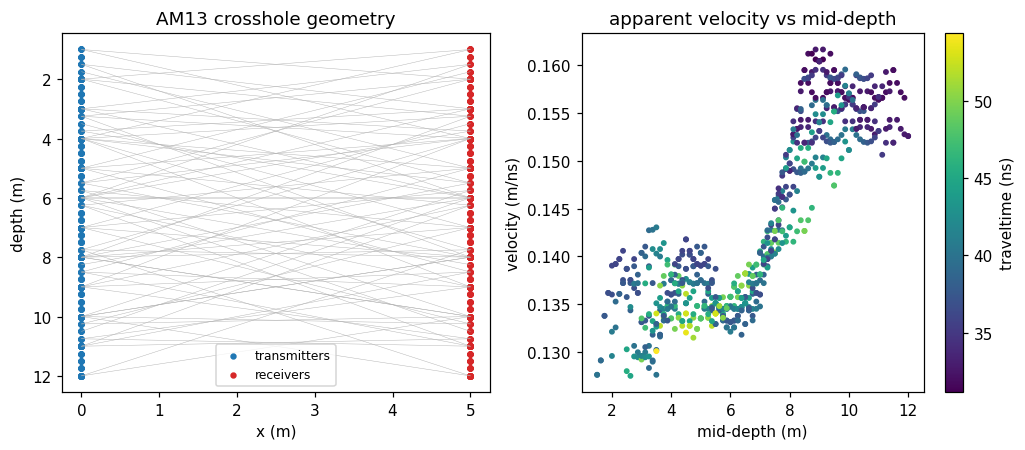

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, time
import matplotlib.pyplot as plt
from scipy.io import loadmat
from mixle_pde.geophysics import eikonal_traveltime, traveltime_tomography, _backtrace_ray, straight_ray_operator, roughness_operator, regularized_gauss_newton
plt.rcParams.update({'figure.dpi': 110})

m = loadmat('../../data/crosshole_gpr/AM13_data.mat')
S, R = m['S'], m['R']; tobs = m['d_obs'].ravel(); tstd = m['d_std'].ravel()
dist = np.linalg.norm(S - R, axis=1)
print('%d rays | boreholes at x=%.0f and x=%.0f m | depth %.0f-%.0f m | traveltime %.1f-%.1f ns'
      % (len(tobs), S[0,0], R[0,0], min(S[:,1].min(),R[:,1].min()), max(S[:,1].max(),R[:,1].max()), tobs.min(), tobs.max()))
print('apparent velocity %.3f +/- %.3f m/ns (moist glaciofluvial sand)' % (np.median(dist/tobs), (dist/tobs).std()))

fig, ax = plt.subplots(1, 2, figsize=(9.5, 4.2))
for k in range(0, len(tobs), 9):
    ax[0].plot([S[k,0], R[k,0]], [S[k,1], R[k,1]], '-', color='0.7', lw=0.3)
ax[0].scatter(S[:,0], S[:,1], c='C0', s=10, label='transmitters'); ax[0].scatter(R[:,0], R[:,1], c='C3', s=10, label='receivers')
ax[0].set(title='AM13 crosshole geometry', xlabel='x (m)', ylabel='depth (m)'); ax[0].invert_yaxis(); ax[0].legend(fontsize=8)
sc = ax[1].scatter((S[:,1]+R[:,1])/2, dist/tobs, c=tobs, cmap='viridis', s=8)
ax[1].set(title='apparent velocity vs mid-depth', xlabel='mid-depth (m)', ylabel='velocity (m/ns)'); fig.colorbar(sc, ax=ax[1], label='traveltime (ns)')
plt.tight_layout(); plt.show()

## 2. The forward problem: rays in a velocity field

The first-arrival traveltime field $T(\mathbf x)$ from a source obeys the **eikonal equation**

$$|\nabla T(\mathbf x)| = s(\mathbf x) = 1/v(\mathbf x),$$

with $T=0$ at the source. Its level sets are the **wavefronts**, and rays run perpendicular to them — curving
toward fast ground. We solve it on a grid with the **fast-sweeping method** (`eikonal_traveltime`): Gauss–Seidel
sweeps in alternating directions, each propagating information along one family of characteristics. Below is the
traveltime field from a single transmitter through a uniform medium — concentric wavefronts, as expected; in a
heterogeneous medium they would distort, and that distortion is the signal tomography reads.

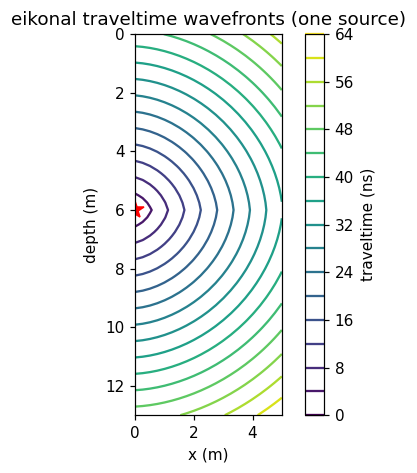

grid 21 x 53 = 1113 cells; 702 rays from 45 sources


In [2]:
# discretize the interborehole plane: x in [0,5], depth in [0,13]
h = 0.25; nx = int(round(5.0/h))+1; nz = int(round(13.0/h))+1; N = nx*nz
def to_idx(x, z): return int(round(x/h))*nz + int(round(z/h))
src = np.array([to_idx(S[k,0], S[k,1]) for k in range(len(tobs))])
rcv = np.array([to_idx(R[k,0], R[k,1]) for k in range(len(tobs))])
s_app = np.median(tobs/dist)                                   # apparent slowness, ns/m

T0 = eikonal_traveltime(np.full(N, s_app), (nx, nz), to_idx(0.0, 6.0), spacing=h).reshape(nx, nz)
fig, ax = plt.subplots(figsize=(4.6, 4.4))
cs = ax.contour(np.linspace(0,5,nx), np.linspace(0,13,nz), T0.T, levels=15, cmap='viridis')
ax.plot(0, 6, 'r*', ms=12); ax.set(title='eikonal traveltime wavefronts (one source)', xlabel='x (m)', ylabel='depth (m)', aspect='equal')
ax.invert_yaxis(); fig.colorbar(cs, label='traveltime (ns)'); plt.tight_layout(); plt.show()
print('grid %d x %d = %d cells; %d rays from %d sources' % (nx, nz, N, len(tobs), len(np.unique(src))))

## 3. Tomography: inverting for the velocity image

We invert the 702 traveltimes for the 2-D slowness with **regularized Gauss–Newton** (`traveltime_tomography`):
each iteration solves the eikonal from every source, predicts the traveltimes, builds the **ray-path Jacobian**
by back-tracing the traveltime gradient from each receiver to its source, and takes a smoothness-regularized
step. Because the rays bend with the model, the procedure is nonlinear. The recovered velocity image fits the
data **to the noise floor**.

eikonal tomography in 1s
data fit: rms residual 0.90 ns (data noise 0.80 ns) -> fits to the noise
velocity 0.136-0.163 m/ns


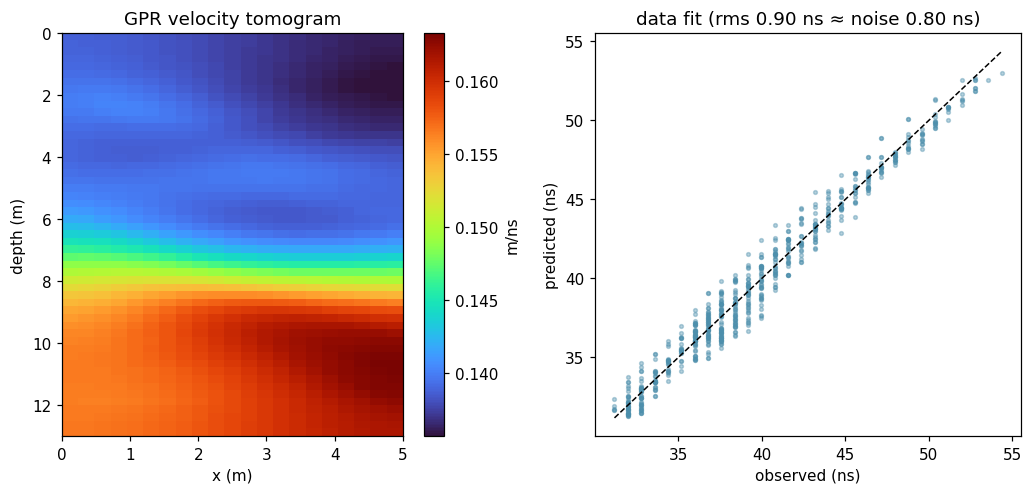

In [3]:
t0 = time.time()
slow, vel, tpred = traveltime_tomography(tobs, src, rcv, (nx, nz), spacing=h, slowness0=s_app,
                                         noise=tstd, beta=20.0, n_iter=6, bounds=(3.0, 12.0))
print('eikonal tomography in %.0fs' % (time.time()-t0))
rms = np.sqrt(((tpred-tobs)**2).mean())
print('data fit: rms residual %.2f ns (data noise %.2f ns) -> fits to the noise' % (rms, tstd.mean()))
print('velocity %.3f-%.3f m/ns' % (vel.min(), vel.max()))
V = vel.reshape(nx, nz)
fig, ax = plt.subplots(1, 2, figsize=(9.5, 4.6))
im = ax[0].imshow(V.T, origin='upper', extent=[0,5,13,0], aspect='auto', cmap='turbo')
ax[0].set(title='GPR velocity tomogram', xlabel='x (m)', ylabel='depth (m)'); fig.colorbar(im, ax=ax[0], label='m/ns')
ax[1].scatter(tobs, tpred, s=6, alpha=0.4, c='#4d8fac'); lim=[tobs.min(),tobs.max()]; ax[1].plot(lim,lim,'k--',lw=1)
ax[1].set(title='data fit (rms %.2f ns ≈ noise %.2f ns)' % (rms, tstd.mean()), xlabel='observed (ns)', ylabel='predicted (ns)')
plt.tight_layout(); plt.show()

The tomogram resolves horizontal **velocity layering** between the boreholes — faster (drier/denser) and slower
(wetter) bands — at a resolution set by the ray coverage. The fit reaching the 0.8 ns measurement noise means
the model explains the data about as well as the data deserve; pushing harder would only fit noise.

## 4. Straight versus bending rays

Why bother with the eikonal? Because rays are not straight when velocity varies — they bend toward fast ground,
sampling a curved path. We can see it directly: back-tracing the traveltime gradient through the recovered model
gives the true (curved) ray paths. For this mildly heterogeneous site the bending is modest, so a straight-ray
inversion lands close; but the eikonal is the **physically correct** forward, and the gap grows with velocity
contrast — in a strongly heterogeneous or fractured medium, straight-ray tomography is simply wrong.

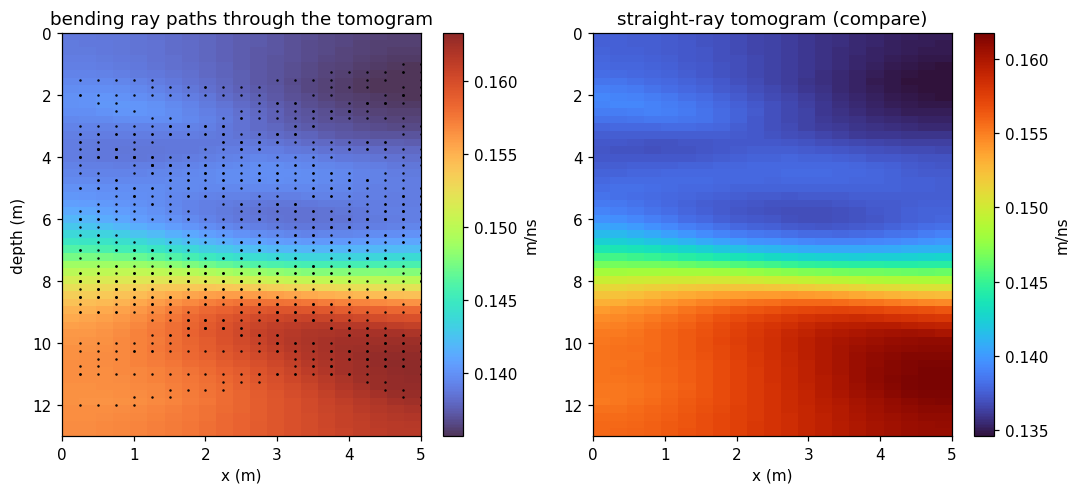

straight-ray vs eikonal velocity: mean abs difference 0.0013 m/ns (small here; grows with contrast)


In [4]:
# true (bending) ray paths through the recovered model, from the eikonal traveltime fields
fig, ax = plt.subplots(1, 2, figsize=(10, 4.6))
im = ax[0].imshow(V.T, origin='upper', extent=[0,5,13,0], aspect='auto', cmap='turbo', alpha=0.85)
for k in range(0, len(tobs), 18):
    Tk = eikonal_traveltime(slow, (nx, nz), int(src[k]), spacing=h)
    row = _backtrace_ray(Tk, (nx, nz), h, int(rcv[k]), int(src[k]), N)
    ij = np.where(row > 0)[0]
    ax[0].plot((ij//nz)*h, (ij%nz)*h, '.', color='k', ms=1.2)
ax[0].set(title='bending ray paths through the tomogram', xlabel='x (m)', ylabel='depth (m)'); fig.colorbar(im, ax=ax[0], label='m/ns')

# straight-ray tomogram for comparison: build the straight-ray length matrix for all 702 rays
import scipy.sparse as sp
rows=[];cols=[];data=[]
for k in range(len(tobs)):
    a=np.array([0.0,(src[k]%nz)*h]); b=np.array([5.0,(rcv[k]%nz)*h]); t=np.linspace(0,1,60)[:,None]; p=a+(b-a)*t
    ii=np.clip(np.round(p[:,0]/h).astype(int),0,nx-1); jj=np.clip(np.round(p[:,1]/h).astype(int),0,nz-1)
    seg=np.linalg.norm(b-a)/59; cell=ii*nz+jj
    for c in np.unique(cell):
        rows.append(k); cols.append(int(c)); data.append(seg*(cell==c).sum())
Ls=sp.csr_matrix((data,(rows,cols)),shape=(len(tobs),N))
import torch; torch.set_default_dtype(torch.float64); Lt=torch.as_tensor(Ls.toarray())
Rg=roughness_operator((nx,nz),spacing=h)
s_str,_=regularized_gauss_newton(lambda u:Lt@u,tobs,np.full(N,s_app),noise=tstd,beta=20.,roughness=Rg,lower=3.,upper=12.,n_iter=4,jac_every=99)
im=ax[1].imshow((1/s_str).reshape(nx,nz).T,origin='upper',extent=[0,5,13,0],aspect='auto',cmap='turbo')
ax[1].set(title='straight-ray tomogram (compare)',xlabel='x (m)'); fig.colorbar(im,ax=ax[1],label='m/ns')
plt.tight_layout(); plt.show()
print('straight-ray vs eikonal velocity: mean abs difference %.4f m/ns (small here; grows with contrast)'
      % np.mean(np.abs(1/s_str - vel)))

## 5. From velocity to water content

The reason a hydrogeologist runs this survey: EM velocity converts to **volumetric water content**. Velocity
sets the bulk dielectric permittivity, $\varepsilon = (c/v)^2$ (with $c=0.3$ m/ns), and **Topp's equation**
(1980) — a calibrated empirical relation — turns permittivity into water content $\theta$. Applying it to the
tomogram yields a **moisture image** of the ground between the boreholes: the quantitative product of the whole
exercise.

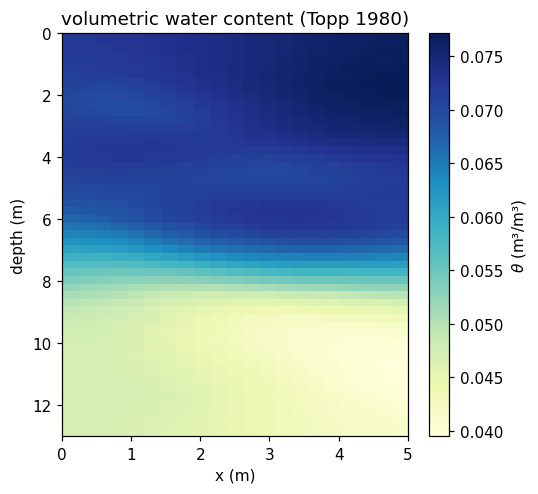

water content 0.04-0.08 m3/m3 -> moist, UNSATURATED sand (the vadose zone above the water table)


In [5]:
eps = (0.3 / V) ** 2                                           # bulk relative permittivity
theta = -5.3e-2 + 2.92e-2*eps - 5.5e-4*eps**2 + 4.3e-6*eps**3   # Topp (1980)
fig, ax = plt.subplots(figsize=(5.0, 4.6))
im = ax.imshow(theta.T, origin='upper', extent=[0,5,13,0], aspect='auto', cmap='YlGnBu')
ax.set(title='volumetric water content (Topp 1980)', xlabel='x (m)', ylabel='depth (m)'); fig.colorbar(im, ax=ax, label=r'$\theta$ (m³/m³)')
plt.tight_layout(); plt.show()
print('water content %.2f-%.2f m3/m3 -> moist, UNSATURATED sand (the vadose zone above the water table)' % (theta.min(), theta.max()))

## Summary, limitations, and references

On a **real** crosshole GPR survey:

1. First-arrival traveltimes are a CT-like view of the velocity between two boreholes.
2. The correct forward model is the **eikonal equation** — rays bend toward fast ground — solved with a
   fast-sweeping solver; the tomography is therefore **nonlinear** (rays re-route as the model updates), unlike
   the trivial straight-ray approximation.
3. **Regularized Gauss–Newton** with the ray-backtraced Jacobian inverts the 702 traveltimes to a velocity
   image that fits the data **to the 0.8 ns measurement noise**.
4. Velocity converts, through **Topp's equation**, into a **water-content** image — the hydrogeological answer.

**Limitations.** First-arrival traveltime tomography is **band-limited and ray-coverage-limited**: it smooths
structure smaller than the Fresnel zone and is blind where no rays cross (the corners). It uses only the first
arrival, discarding the rest of the waveform (full-waveform inversion uses it all, at much greater cost). The
2-D assumption ignores out-of-plane structure. Topp's equation is empirical and soil-dependent. We regularize
with smoothness, which — as always — *chooses* one image among those that fit. The provided data covariance
could weight the misfit more rigorously than the per-datum standard deviation used here.

**References.**
- M. C. Looms, T. M. Hansen, K. S. Cordua, L. Nielsen, K. H. Jensen, A. Binley (2010), *Geostatistical
  inference using crosshole ground-penetrating radar*, Geophysics 75(6), J29–J41.
- H. Zhao (2005), *A fast sweeping method for eikonal equations*, Math. Comp. 74, 603–627.
- N. Rawlinson & M. Sambridge (2005), *The fast marching method: an effective tool for tomographic imaging and
  tracking multiple phases in complex layered media*, Exploration Geophysics 36, 341–350.
- G. C. Topp, J. L. Davis, A. P. Annan (1980), *Electromagnetic determination of soil water content*, Water
  Resour. Res. 16(3), 574–582.

**Exercises.**
1. **Resolution.** Run a checkerboard test — plant alternating fast/slow blocks, forward through the eikonal,
   invert, and map where the survey resolves them (the ray-coverage gaps).
2. **Contrast.** Increase the velocity heterogeneity in a synthetic and watch the straight-ray and eikonal
   tomograms diverge — quantify when bending can no longer be ignored.
3. **Covariance weighting.** Use the full data covariance `Ct` (in the .mat file) as the misfit weight instead
   of the per-datum standard deviation, and compare.
4. **Joint with ERT.** Add a crosshole ERT survey and couple the velocity and conductivity images with
   `cross_gradient` (see the near-surface joint-inversion notebook).